# 08 — N-Body Deep Dive

**Winner: C++** (~36.7 J) — virtually tied with C (~38.7 J, 1.05×) and Rust (~42 J, 1.14×).

Notable patterns:
- **The systems-language trio (C++, C, Rust) dominates** — `n-body` is a pure floating-point physics simulation; manual memory management and direct hardware access win.
- **F# (4th, ~50 J) and Swift (5th, ~56 J)** punch above their weight, ahead of Go, C#, Java.
- **Haskell is 12th (~117 J, 3.2×)** — purely numerical workloads are not a GC strength.
- **Python is worst** (~5 942 J, 162× worse than C++) — the largest ratio among the interpreted group for a numeric benchmark.
- A clear **two-tier split**: compiled languages ≤ 120 J vs interpreted languages ≥ 1 640 J.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BENCHMARK = 'n-body'
RUNS_CSV  = Path('../results/results_clean_runs.csv')
MEAN_CSV  = Path('../results/results_clean.csv')
FIGS_DIR  = Path('../results/figs/n_body')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

def save(name): plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight'); plt.show()
def find_col(df, kw): return next(c for c in df.columns if kw in c)
unit = lambda col: col.rsplit('-', 1)[-1].upper()

---
## 1. Load data

In [2]:
bt_runs  = pd.read_csv(RUNS_CSV)
bt_runs  = bt_runs[bt_runs['benchmark'] == BENCHMARK].copy()
bt_means = pd.read_csv(MEAN_CSV)
bt_means = bt_means[bt_means['benchmark'] == BENCHMARK].set_index('language')

COL_CPU_E  = find_col(bt_runs, 'cpu_energy')
COL_MEM_E  = find_col(bt_runs, 'memory_energy')
COL_CARBON = find_col(bt_runs, 'cpu_carbon')
COL_TIME   = find_col(bt_runs, 'phase_time')

print(f'Per-run rows: {len(bt_runs)} | Mean rows: {len(bt_means)}')
bt_means[[COL_CPU_E, COL_TIME]].sort_values(COL_CPU_E).round(3)

Per-run rows: 147 | Mean rows: 18


,cpu_energy_rapl_msr_component-package_0-j,phase_time_syscall_system-system-s
language,,
cpp,36.439,2.397
c,38.665,2.516
rust,41.784,2.767
fsharp,50.061,2.844
swift,55.876,3.506
go,58.624,4.033
csharp,61.445,4.395
java,66.261,3.907
ocaml,68.769,4.648


---
## 2. Strip plot — per-run consistency

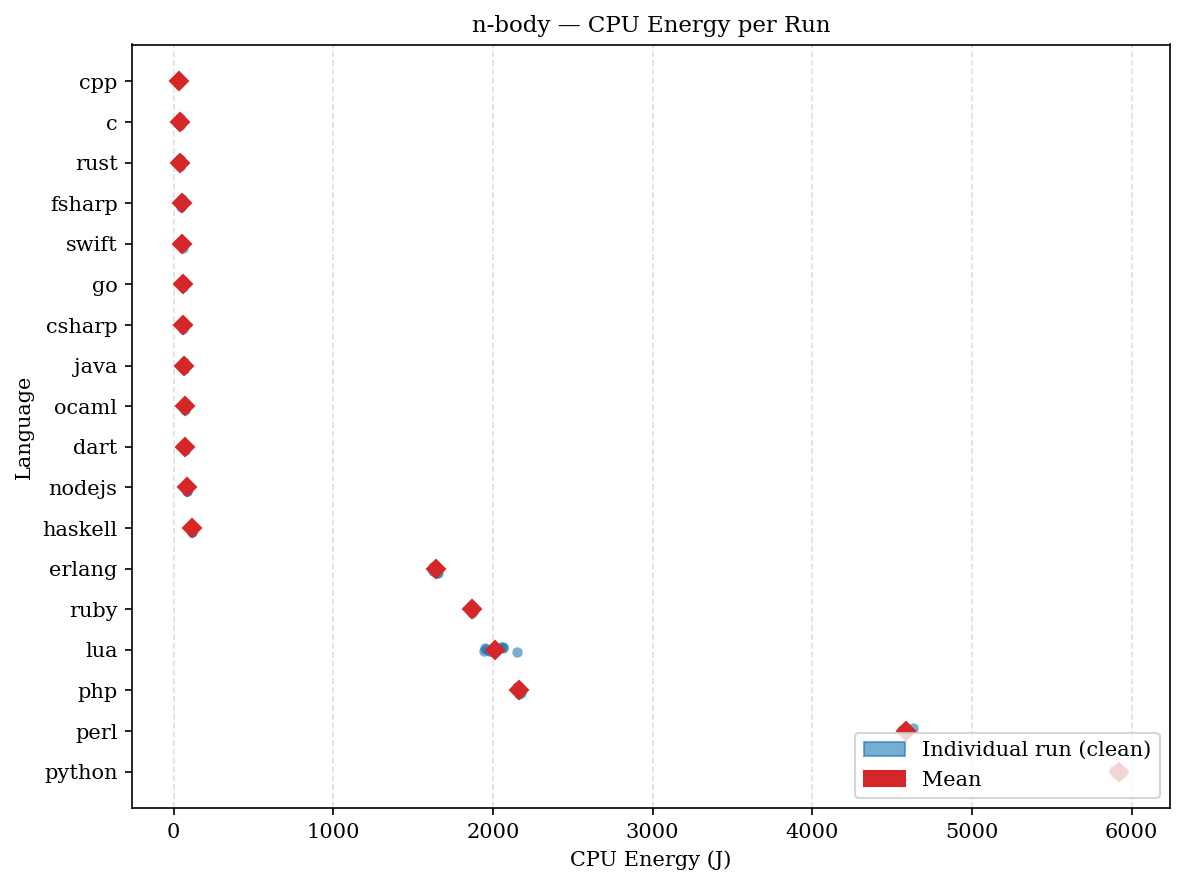

In [3]:
order = bt_means[COL_CPU_E].sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=bt_runs, x=COL_CPU_E, y='language', order=order,
              jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax)
for i, lang in enumerate(order):
    ax.plot(bt_means.loc[lang, COL_CPU_E], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.legend(handles=[
    mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run (clean)'),
    mpatches.Patch(color='#d62728', label='Mean'),
], loc='lower right')
ax.set_xlabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_ylabel('Language')
ax.set_title(f'{BENCHMARK} — CPU Energy per Run')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stripplot_cpu_energy')

---
## 3. Ranked bar — two-tier gap visualised

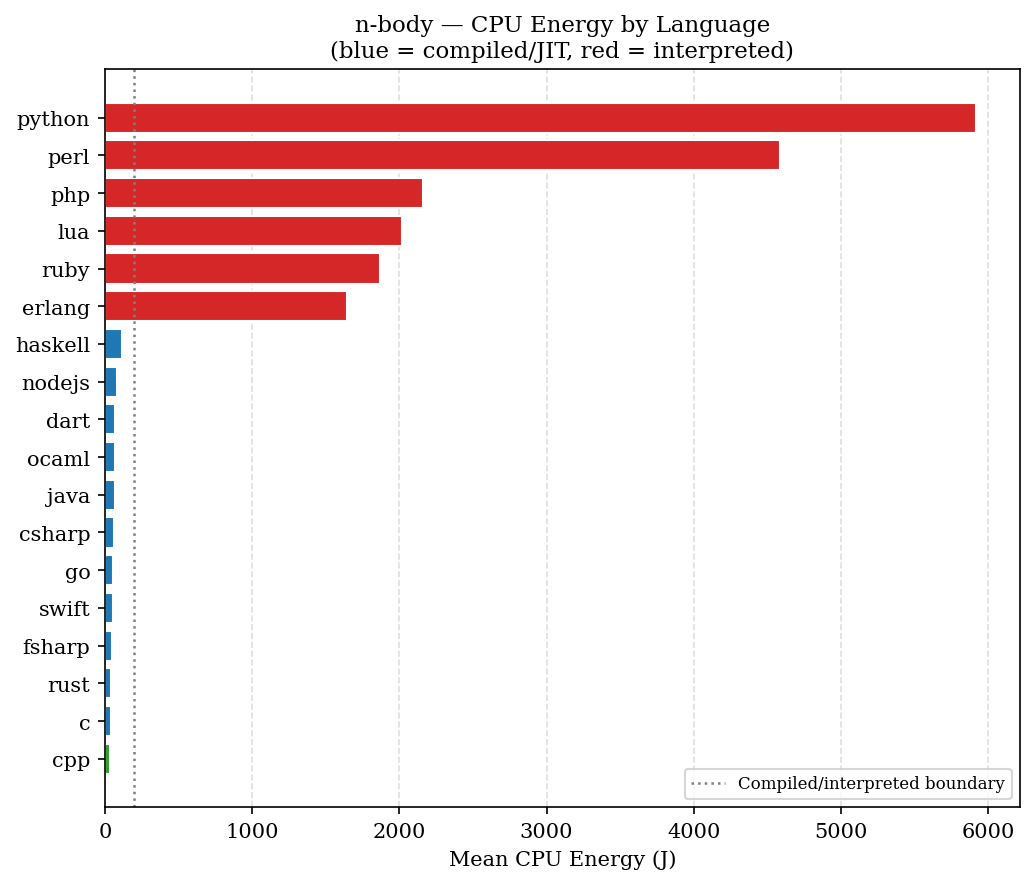

In [4]:
means = bt_means.sort_values(COL_CPU_E)
winner = means.index[0]

COMPILED_THRESHOLD = 200  # J — boundary between tiers
colors = ['#2ca02c' if i == 0 else ('#1f77b4' if v < COMPILED_THRESHOLD else '#d62728')
          for i, v in enumerate(means[COL_CPU_E])]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(means.index, means[COL_CPU_E], color=colors, edgecolor='white')

ax.axvline(COMPILED_THRESHOLD, color='grey', linestyle=':', linewidth=1.2, label='Compiled/interpreted boundary')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — CPU Energy by Language\n(blue = compiled/JIT, red = interpreted)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_cpu_energy')

---
## 4. Normalised to winner

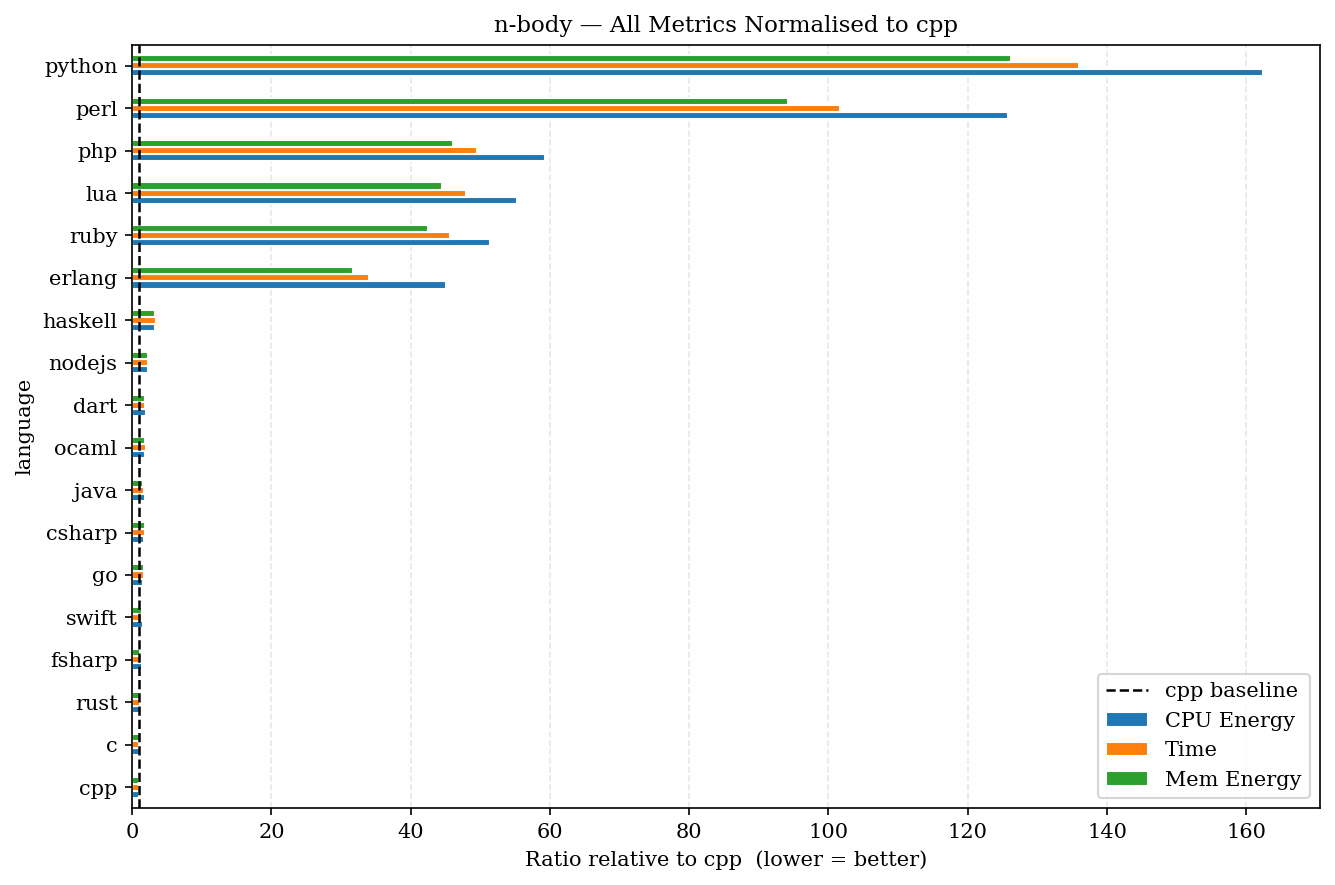

In [5]:
subset = means[[COL_CPU_E, COL_TIME, COL_MEM_E]]
ratio = subset.div(subset.loc[winner])
ratio.columns = ['CPU Energy', 'Time', 'Mem Energy']

fig, ax = plt.subplots(figsize=(9, 6))
ratio.plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label=f'{winner} baseline')
ax.set_xlabel(f'Ratio relative to {winner}  (lower = better)')
ax.set_title(f'{BENCHMARK} — All Metrics Normalised to {winner}')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save('normalised')

---
## 5. Energy vs. Time scatter

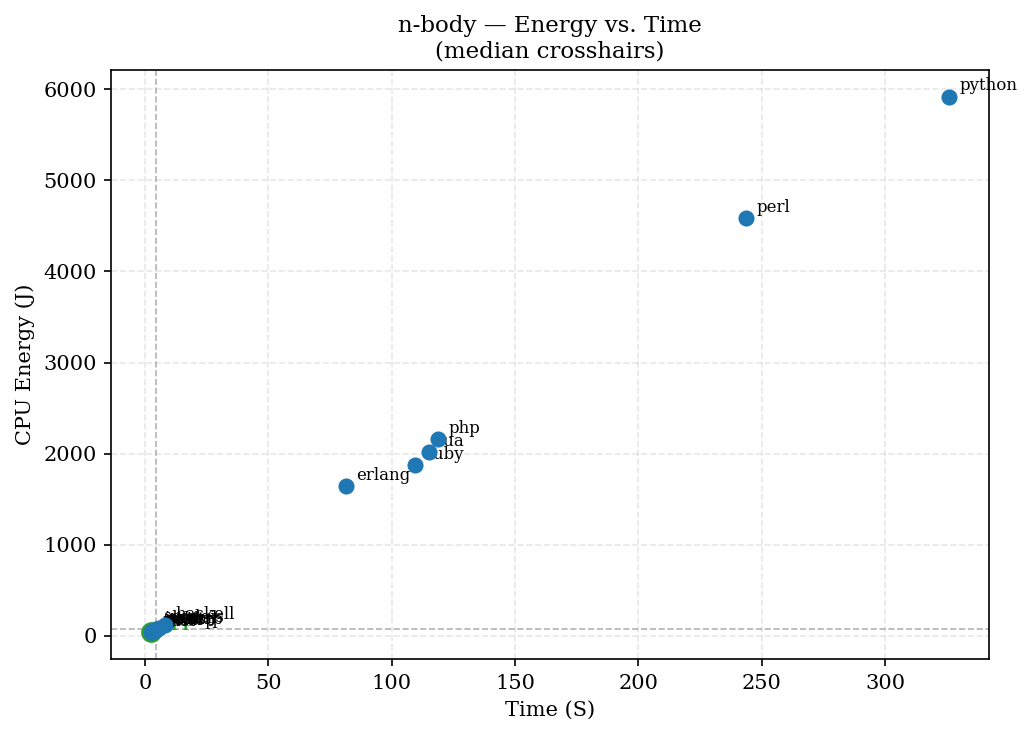

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for lang, row in means.iterrows():
    color = '#2ca02c' if lang == winner else '#1f77b4'
    ax.scatter(row[COL_TIME], row[COL_CPU_E], color=color, s=80 if lang == winner else 45, zorder=3)
    ax.annotate(lang, (row[COL_TIME], row[COL_CPU_E]),
                textcoords='offset points', xytext=(5, 3), fontsize=8,
                color='#2ca02c' if lang == winner else 'black',
                fontweight='bold' if lang == winner else 'normal')

ax.axvline(means[COL_TIME].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(means[COL_CPU_E].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel(f'Time ({unit(COL_TIME)})')
ax.set_ylabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — Energy vs. Time\n(median crosshairs)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 6. Summary table

In [7]:
summary = means[[COL_CPU_E, COL_TIME, COL_MEM_E, COL_CARBON]].copy()
summary.columns = [f'CPU Energy ({unit(COL_CPU_E)})', f'Time ({unit(COL_TIME)})',
                   f'Mem Energy ({unit(COL_MEM_E)})', f'CPU Carbon ({unit(COL_CARBON)})']
summary.round(4)

,CPU Energy (J),Time (S),Mem Energy (J),CPU Carbon (G)
language,,,,
cpp,36.4389,2.3972,0.7346,0.0034
c,38.6645,2.5160,0.7783,0.0036
rust,41.7842,2.7671,0.8556,0.0039
fsharp,50.0612,2.8440,0.8751,0.0046
swift,55.8759,3.5062,1.0699,0.0052
go,58.6239,4.0332,1.2153,0.0054
csharp,61.4446,4.3950,1.3125,0.0057
java,66.2608,3.9069,1.1947,0.0061
ocaml,68.7685,4.6480,1.4005,0.0064
